# Task 2: Exploratory Data Analysis

## Forecasting Financial Inclusion in Ethiopia

This notebook explores the enriched financial inclusion dataset, evaluates
data quality, analyzes Access and Usage indicators, visualizes major events,
and identifies preliminary relationships that will guide the forecasting
phase.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ethiopia_fi_enriched.csv"
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

for column in ["observation_date", "event_date"]:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

if "value_numeric" in df.columns:
    df["value_numeric"] = pd.to_numeric(
        df["value_numeric"],
        errors="coerce"
    )

df["record_type_normalized"] = (
    df["record_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["pillar_normalized"] = (
    df["pillar"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Dataset path: /Users/mac/Ethiopia-FI-Interim/data/processed/ethiopia_fi_enriched.csv
Dataset shape: (62, 37)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id,record_type_normalized,pillar_normalized
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,NaN,observation,ACCESS
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN,observation,ACCESS
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN,observation,ACCESS
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN,observation,ACCESS
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN,observation,ACCESS


In [2]:
print("Dataset dimensions")
print("------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

summary_columns = [
    "record_type",
    "pillar",
    "source_type",
    "confidence"
]

for column in summary_columns:
    if column in df.columns:
        print(f"\nCounts by {column}")

        summary = (
            df[column]
            .fillna("Missing")
            .value_counts(dropna=False)
            .rename_axis(column)
            .reset_index(name="count")
        )

        display(summary)

Dataset dimensions
------------------
Rows: 62
Columns: 37

Counts by record_type


,record_type,count
0,observation,33
1,impact_link,15
2,event,11
3,target,3



Counts by pillar


,pillar,count
0,ACCESS,21
1,USAGE,20
2,Missing,11
3,GENDER,6
4,AFFORDABILITY,4



Counts by source_type


,source_type,count
0,Missing,19
1,operator,15
2,survey,10
3,regulator,7
4,research,4
5,policy,3
6,calculated,2
7,news,2



Counts by confidence


,confidence,count
0,high,48
1,medium,14


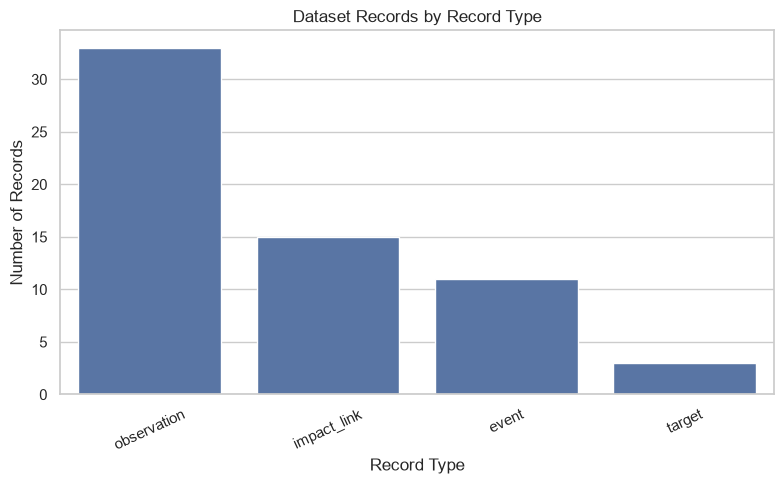

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/records_by_type.png


In [3]:
record_counts = (
    df["record_type_normalized"]
    .value_counts()
    .rename_axis("record_type")
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=record_counts,
    x="record_type",
    y="count"
)

plt.title("Dataset Records by Record Type")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=25)
plt.tight_layout()

output_file = FIGURE_DIR / "records_by_type.png"
plt.savefig(output_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", output_file)

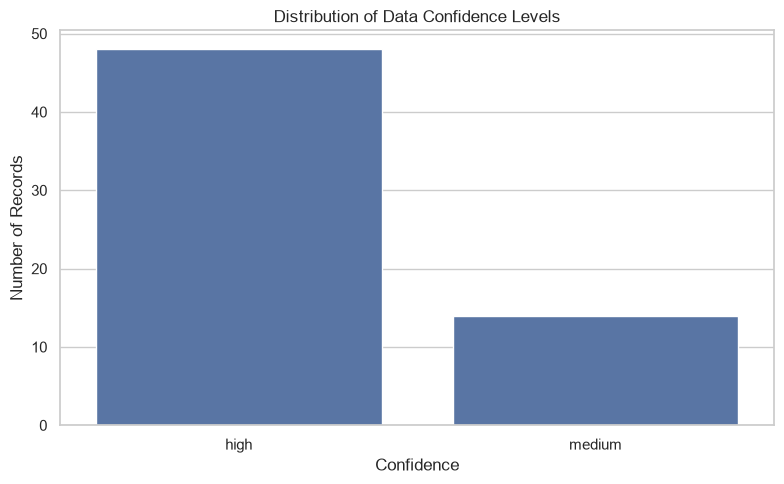

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/confidence_distribution.png


In [4]:
if "confidence" in df.columns:
    confidence_counts = (
        df["confidence"]
        .fillna("Missing")
        .value_counts()
        .rename_axis("confidence")
        .reset_index(name="count")
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=confidence_counts,
        x="confidence",
        y="count"
    )

    plt.title("Distribution of Data Confidence Levels")
    plt.xlabel("Confidence")
    plt.ylabel("Number of Records")
    plt.tight_layout()

    output_file = FIGURE_DIR / "confidence_distribution.png"
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_file)

year,2014.0,2017.0,2021.0,2023.0,2024.0,2025.0
indicator_code,,,,,,
ACC_4G_COV,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,1,2
ACC_MM_ACCOUNT,0,0,1,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,1
ACC_OWNERSHIP,1,1,3,0,1,0
AFF_DATA_INCOME,0,0,0,0,1,0
GEN_GAP_ACC,0,0,1,0,1,0
GEN_GAP_MOBILE,0,0,0,0,1,0
GEN_MM_SHARE,0,0,0,0,1,0


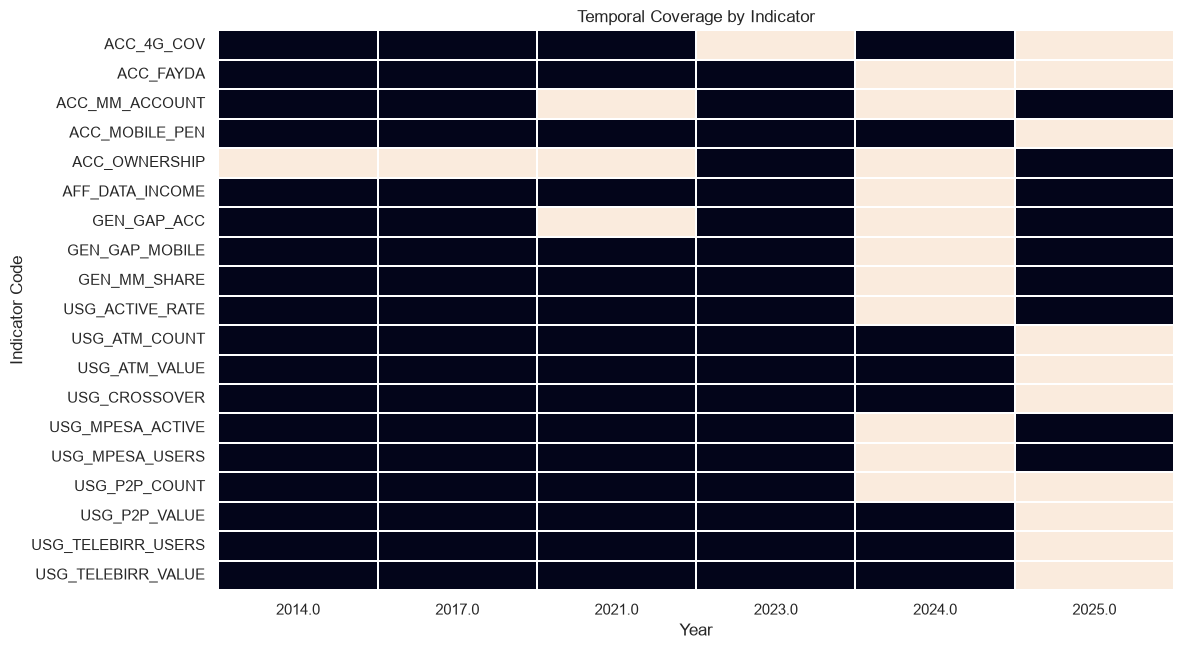

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/temporal_coverage.png


In [5]:
observations = df[
    df["record_type_normalized"].eq("observation")
].copy()

observations["year"] = observations[
    "observation_date"
].dt.year

coverage = pd.crosstab(
    observations["indicator_code"],
    observations["year"]
)

display(coverage)

if not coverage.empty:
    plt.figure(
        figsize=(
            12,
            max(6, len(coverage) * 0.35)
        )
    )

    sns.heatmap(
        coverage.gt(0).astype(int),
        cbar=False,
        linewidths=0.3
    )

    plt.title("Temporal Coverage by Indicator")
    plt.xlabel("Year")
    plt.ylabel("Indicator Code")
    plt.tight_layout()

    output_file = FIGURE_DIR / "temporal_coverage.png"
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_file)

,year,value_numeric,source_name,confidence,change_pp
0,2011,14.0,Global Findex 2011,high,NaN
1,2014,22.0,Global Findex 2014,high,8.0
2,2017,35.0,Global Findex 2017,high,13.0
3,2021,46.0,Global Findex 2021,high,11.0
4,2024,49.0,Global Findex 2024,high,3.0


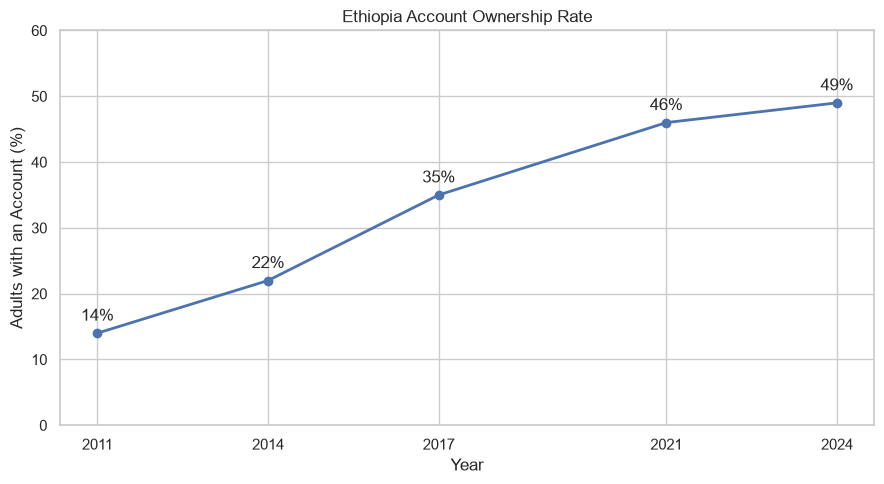

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/account_ownership_trajectory.png


In [6]:


account_ownership = pd.DataFrame({
    "year": [2011, 2014, 2017, 2021, 2024],
    "value_numeric": [14.0, 22.0, 35.0, 46.0, 49.0],
    "source_name": [
        "Global Findex 2011",
        "Global Findex 2014",
        "Global Findex 2017",
        "Global Findex 2021",
        "Global Findex 2024"
    ],
    "confidence": ["high", "high", "high", "high", "high"]
})

account_ownership["change_pp"] = (
    account_ownership["value_numeric"].diff()
)

display(account_ownership)

# Validate the national series
assert account_ownership["year"].tolist() == [
    2011, 2014, 2017, 2021, 2024
]

assert account_ownership["value_numeric"].tolist() == [
    14.0, 22.0, 35.0, 46.0, 49.0
]

plt.figure(figsize=(9, 5))

plt.plot(
    account_ownership["year"],
    account_ownership["value_numeric"],
    marker="o",
    linewidth=2
)

for _, row in account_ownership.iterrows():
    plt.annotate(
        f'{row["value_numeric"]:.0f}%',
        (row["year"], row["value_numeric"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center"
    )

plt.title("Ethiopia Account Ownership Rate")
plt.xlabel("Year")
plt.ylabel("Adults with an Account (%)")
plt.xticks(account_ownership["year"])
plt.ylim(0, 60)
plt.tight_layout()

output_file = (
    FIGURE_DIR
    / "account_ownership_trajectory.png"
)

plt.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file)

,interval,change_pp
0,2011–2014,8.0
1,2014–2017,13.0
2,2017–2021,11.0
3,2021–2024,3.0


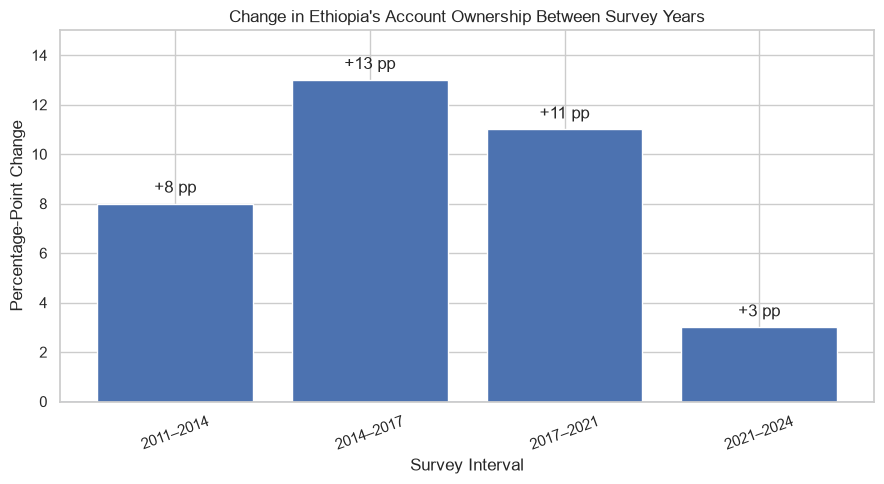

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/account_ownership_growth.png


In [7]:

growth_data = account_ownership.copy()

growth_data["previous_year"] = growth_data["year"].shift(1)
growth_data["change_pp"] = growth_data["value_numeric"].diff()

growth_data = growth_data.dropna(
    subset=["previous_year", "change_pp"]
).copy()

growth_data["previous_year"] = (
    growth_data["previous_year"].astype(int)
)

growth_data["year"] = growth_data["year"].astype(int)

growth_data["interval"] = (
    growth_data["previous_year"].astype(str)
    + "–"
    + growth_data["year"].astype(str)
)

growth_data = growth_data.reset_index(drop=True)

display(
    growth_data[
        [
            "interval",
            "change_pp"
        ]
    ]
)

# Validate the expected changes
expected_changes = [8.0, 13.0, 11.0, 3.0]

assert growth_data["change_pp"].tolist() == expected_changes, (
    "Unexpected growth values: "
    f"{growth_data['change_pp'].tolist()}"
)

# Create the growth chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    growth_data["interval"],
    growth_data["change_pp"]
)

# Display each value above its bar
for bar, value in zip(
    bars,
    growth_data["change_pp"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"+{value:.0f} pp",
        ha="center",
        va="bottom"
    )

plt.axhline(0, linewidth=1)

plt.title(
    "Change in Ethiopia's Account Ownership Between Survey Years"
)

plt.xlabel("Survey Interval")
plt.ylabel("Percentage-Point Change")
plt.ylim(0, 15)
plt.xticks(rotation=20)
plt.tight_layout()

output_file = (
    FIGURE_DIR
    / "account_ownership_growth.png"
)

plt.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file)

In [8]:
usage = observations[
    observations["pillar_normalized"].eq("USAGE")
].copy()

usage["year"] = usage["observation_date"].dt.year

usage_summary_columns = [
    column for column in [
        "indicator",
        "indicator_code",
        "year",
        "value_numeric",
        "unit_type",
        "unit",
        "confidence"
    ]
    if column in usage.columns
]

display(
    usage[usage_summary_columns]
    .sort_values(
        ["indicator_code", "year"]
    )
)

,indicator,indicator_code,year,value_numeric,unit,confidence
24,Mobile Money Activity Rate,USG_ACTIVE_RATE,2024.0,6.600000e+01,%,high
17,ATM Transaction Count,USG_ATM_COUNT,2025.0,1.193000e+08,transactions,high
18,ATM Transaction Value,USG_ATM_VALUE,2025.0,1.561000e+11,ETB,high
19,P2P/ATM Crossover Ratio,USG_CROSSOVER,2025.0,1.080000e+00,ratio,high
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE,2024.0,7.100000e+06,users,high
22,M-Pesa Registered Users,USG_MPESA_USERS,2024.0,1.080000e+07,users,high
14,P2P Transaction Count,USG_P2P_COUNT,2024.0,4.970000e+07,transactions,high
15,P2P Transaction Count,USG_P2P_COUNT,2025.0,1.283000e+08,transactions,high
16,P2P Transaction Value,USG_P2P_VALUE,2025.0,5.777000e+11,ETB,high
58,Telebirr Merchant Network Size,USG_TELEBIRR_MERCHANTS,NaN,3.101000e+05,NaN,high


,indicator,indicator_code,year,value_numeric,unit
24,Mobile Money Activity Rate,USG_ACTIVE_RATE,2024,66.0,%


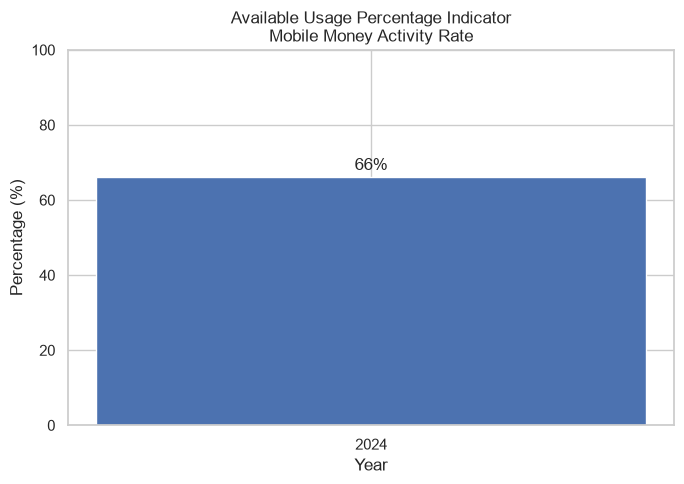

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/usage_trends.png


In [9]:

usage_percent = usage.copy()

unit_text = (
    usage_percent["unit"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

percentage_mask = unit_text.isin(
    ["%", "percent", "percentage"]
)

usage_percent = usage_percent[
    percentage_mask
].copy()

usage_percent = usage_percent[
    usage_percent["value_numeric"].between(0, 100)
].copy()

excluded_pattern = (
    r"COUNT|VALUE|USERS|AGENTS|MERCHANTS|CROSSOVER"
)

usage_percent = usage_percent[
    ~usage_percent["indicator_code"]
    .astype(str)
    .str.contains(
        excluded_pattern,
        case=False,
        na=False,
        regex=True
    )
].copy()

usage_percent = usage_percent.dropna(
    subset=["indicator_code", "year", "value_numeric"]
)

usage_percent["year"] = usage_percent["year"].astype(int)

usage_percent = usage_percent.drop_duplicates(
    subset=["indicator_code", "year", "value_numeric"]
)

display_columns = [
    column for column in [
        "indicator",
        "indicator_code",
        "year",
        "value_numeric",
        "unit"
    ]
    if column in usage_percent.columns
]

display(usage_percent[display_columns])

if len(usage_percent) == 1:
    row = usage_percent.iloc[0]

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        [str(row["year"])],
        [row["value_numeric"]]
    )

    plt.text(
        bars[0].get_x() + bars[0].get_width() / 2,
        row["value_numeric"] + 2,
        f'{row["value_numeric"]:.0f}%',
        ha="center"
    )

    plt.title(
        f'Available Usage Percentage Indicator\n{row["indicator"]}'
    )
    plt.xlabel("Year")
    plt.ylabel("Percentage (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

elif len(usage_percent) > 1:
    plt.figure(figsize=(11, 6))

    for code, group in usage_percent.groupby("indicator_code"):
        group = group.sort_values("year")

        plt.plot(
            group["year"],
            group["value_numeric"],
            marker="o",
            linewidth=2,
            label=code
        )

    plt.title(
        "Percentage-Based Digital Financial Usage Indicators"
    )
    plt.xlabel("Year")
    plt.ylabel("Percentage (%)")
    plt.ylim(0, 100)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()

else:
    print(
        "No valid percentage-based Usage observations were found."
    )

if not usage_percent.empty:
    output_file = FIGURE_DIR / "usage_trends.png"

    plt.savefig(
        output_file,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file)

In [10]:

registered_active_records = observations[
    observations["indicator"]
    .astype(str)
    .str.contains(
        r"registered|active|savings",
        case=False,
        na=False,
        regex=True
    )
].copy()

registered_active_records = (
    registered_active_records
    .sort_values(["indicator_code", "observation_date"])
)

display_columns = [
    column for column in [
        "indicator",
        "indicator_code",
        "value_numeric",
        "observation_date",
        "unit",
        "source_name",
        "confidence"
    ]
    if column in registered_active_records.columns
]

display(registered_active_records[display_columns])

# Display agent and merchant infrastructure separately.
network_records = observations[
    observations["indicator"]
    .astype(str)
    .str.contains(
        r"agent|merchant",
        case=False,
        na=False,
        regex=True
    )
].copy()

network_records = network_records.sort_values(
    ["indicator_code", "observation_date"]
)

print("Agent and merchant network indicators")

display(network_records[display_columns])

,indicator,indicator_code,value_numeric,observation_date,unit,source_name,confidence
23,M-Pesa 90-Day Active Users,USG_MPESA_ACTIVE,7100000.0,2024-12-31,users,Safaricom Results,high
22,M-Pesa Registered Users,USG_MPESA_USERS,10800000.0,2024-12-31,users,Safaricom Results,high
59,Telebirr Digital Savings Customers,USG_TELEBIRR_SAVERS,1770000.0,NaT,NaN,Ethio Telecom 2024/25 Annual Performance Report,high
20,Telebirr Registered Users,USG_TELEBIRR_USERS,54840000.0,2025-06-30,users,Ethio Telecom Report,high


Agent and merchant network indicators


,indicator,indicator_code,value_numeric,observation_date,unit,source_name,confidence
57,Telebirr Agent Network Size,ACC_TELEBIRR_AGENTS,320300.0,NaT,NaN,Ethio Telecom 2024/25 Annual Performance Report,high
58,Telebirr Merchant Network Size,USG_TELEBIRR_MERCHANTS,310100.0,NaT,NaN,Ethio Telecom 2024/25 Annual Performance Report,high


Number of event records: 11
Available event columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'parent_id', 'record_type_normalized', 'pillar_normalized']


,timeline_date,indicator,category,source_name,confidence
0,2021-05-17,Telebirr Launch,product_launch,Ethio Telecom,high
1,2021-09-01,NFIS-II Strategy Launch,policy,NBE,high
2,2022-08-01,Safaricom Ethiopia Commercial Launch,market_entry,News,high
3,2023-08-01,M-Pesa Ethiopia Launch,product_launch,Safaricom,high
4,2024-01-01,Fayda Digital ID Program Rollout,infrastructure,NIDP,high
5,2024-07-29,Foreign Exchange Liberalization,policy,NBE,high
6,2024-10-01,P2P Transaction Count Surpasses ATM,milestone,EthSwitch,high
7,2025-10-27,M-Pesa EthSwitch Integration,partnership,EthSwitch,high
8,2025-12-15,Safaricom Ethiopia Price Increase,pricing,News,high
9,2025-12-18,EthioPay Instant Payment System Launch,infrastructure,NBE/EthSwitch,high


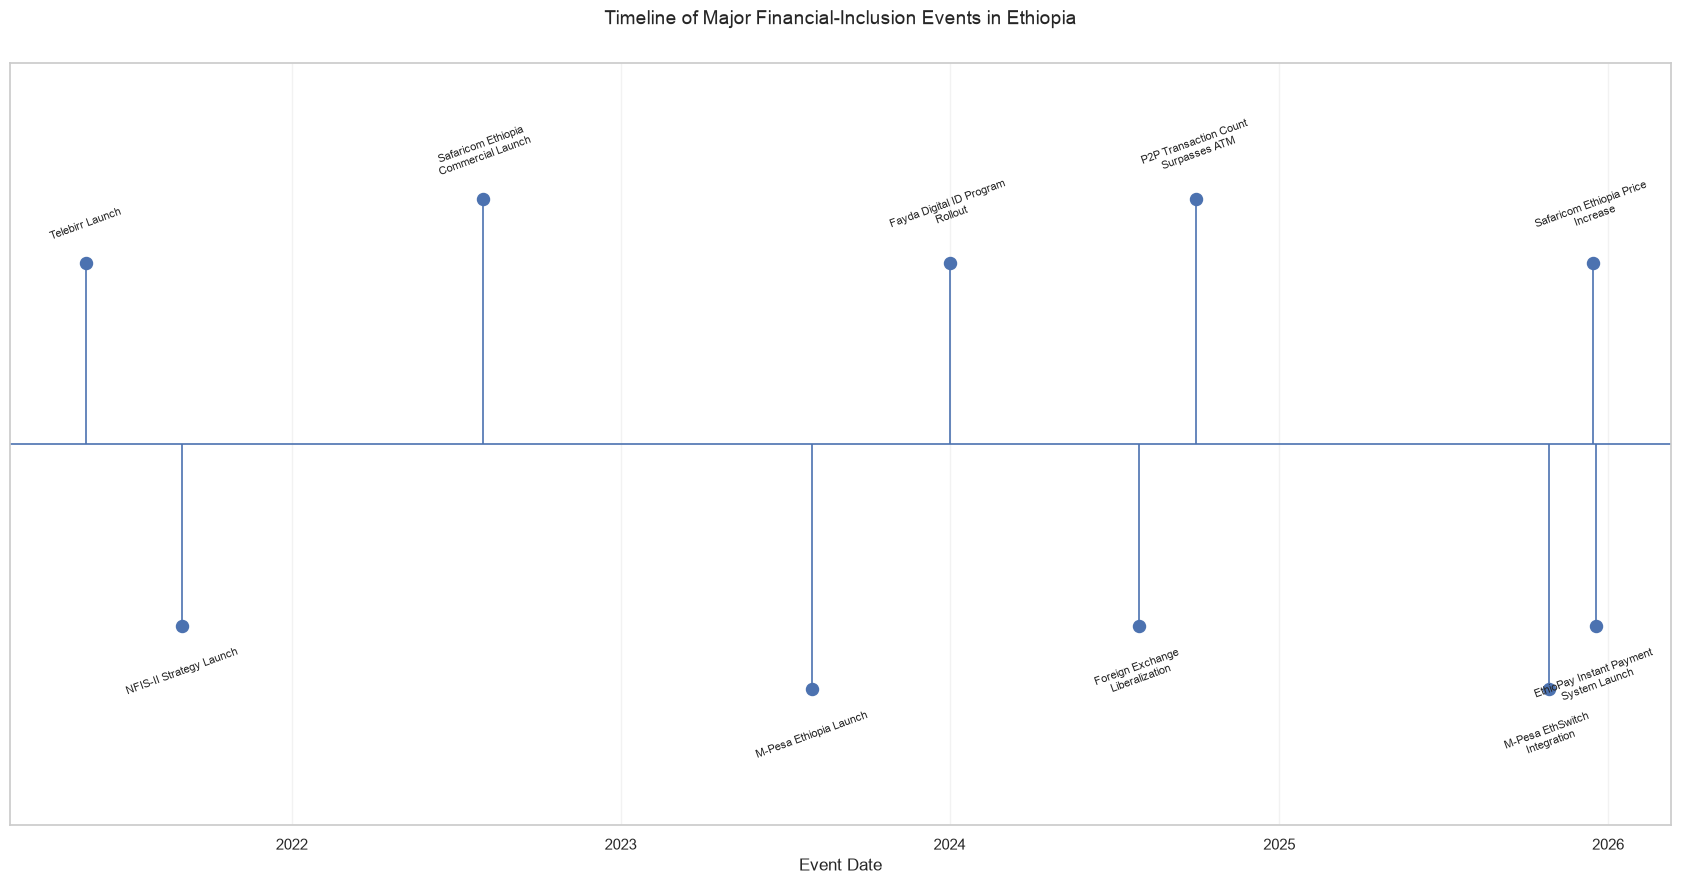

Saved: /Users/mac/Ethiopia-FI-Interim/reports/figures/event_timeline.png


In [11]:


from textwrap import fill

# Select event records
events = df[
    df["record_type_normalized"].eq("event")
].copy()

# Clean column names
events.columns = (
    events.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("Number of event records:", len(events))
print("Available event columns:", events.columns.tolist())

# Find available date columns
date_candidates = [
    column
    for column in [
        "event_date",
        "observation_date",
        "date"
    ]
    if column in events.columns
]

if not date_candidates:
    raise KeyError(
        "No event-date column was found. "
        f"Available columns: {events.columns.tolist()}"
    )

# Create one reliable timeline-date column
events["timeline_date"] = pd.NaT

for column in date_candidates:
    parsed_dates = pd.to_datetime(
        events[column],
        errors="coerce"
    )

    events["timeline_date"] = (
        events["timeline_date"]
        .fillna(parsed_dates)
    )

# Find the best available event-name column
name_candidates = [
    column
    for column in [
        "indicator",
        "event_name",
        "indicator_name",
        "description",
        "indicator_code",
        "record_id"
    ]
    if column in events.columns
]

if not name_candidates:
    raise KeyError(
        "No usable event-name column was found."
    )

event_name_column = name_candidates[0]

# Remove events without valid dates
events = (
    events
    .dropna(subset=["timeline_date"])
    .sort_values("timeline_date")
    .reset_index(drop=True)
)

# Display a clean event table
display_columns = [
    column
    for column in [
        "timeline_date",
        event_name_column,
        "category",
        "source_name",
        "confidence"
    ]
    if column in events.columns
]

display(events[display_columns])

if events.empty:
    print(
        "Event records were found, but none contained valid dates."
    )

else:
    # Use staggered levels to reduce label overlap
    level_pattern = [
        1.0,
        -1.0,
        1.35,
        -1.35
    ]

    events["timeline_level"] = [
        level_pattern[index % len(level_pattern)]
        for index in range(len(events))
    ]

    plt.figure(figsize=(17, 9))

    # Main horizontal timeline
    plt.axhline(
        y=0,
        linewidth=1.2
    )

    # Vertical connectors
    plt.vlines(
        x=events["timeline_date"],
        ymin=0,
        ymax=events["timeline_level"],
        linewidth=1.2
    )

    # Event points
    plt.scatter(
        events["timeline_date"],
        events["timeline_level"],
        s=75,
        zorder=3
    )

    # Event labels
    for _, row in events.iterrows():
        event_label = fill(
            str(row[event_name_column]),
            width=24
        )

        is_above = row["timeline_level"] > 0

        plt.annotate(
            event_label,
            (
                row["timeline_date"],
                row["timeline_level"]
            ),
            xytext=(
                0,
                15 if is_above else -15
            ),
            textcoords="offset points",
            ha="center",
            va="bottom" if is_above else "top",
            rotation=20,
            fontsize=8
        )

    # Improve spacing and presentation
    plt.ylim(-2.1, 2.1)
    plt.yticks([])

    plt.title(
        "Timeline of Major Financial-Inclusion Events in Ethiopia",
        fontsize=14,
        pad=28
    )

    plt.xlabel("Event Date")
    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()

    # Save the figure
    output_file = (
        FIGURE_DIR
        / "event_timeline.png"
    )

    plt.savefig(
        output_file,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_file)

In [12]:
correlation_data = observations.dropna(
    subset=[
        "indicator_code",
        "observation_date",
        "value_numeric"
    ]
).copy()

correlation_data["year"] = (
    correlation_data["observation_date"].dt.year
)

annual_indicators = correlation_data.pivot_table(
    index="year",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean"
)

eligible_indicators = annual_indicators.columns[
    annual_indicators.notna().sum() >= 3
]

correlation_matrix = annual_indicators[
    eligible_indicators
].corr(min_periods=3)

display(correlation_matrix)

if correlation_matrix.shape[0] > 1:
    plt.figure(
        figsize=(
            max(8, correlation_matrix.shape[0] * 0.7),
            max(6, correlation_matrix.shape[0] * 0.6)
        )
    )

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        center=0
    )

    plt.title(
        "Correlation Matrix for Indicators with Sufficient Coverage"
    )
    plt.tight_layout()

    output_file = FIGURE_DIR / "correlation_matrix.png"
    plt.savefig(
        output_file,
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    print("Saved:", output_file)
else:
    print(
        "Insufficient overlapping observations for "
        "a reliable correlation heatmap."
    )

indicator_code,ACC_OWNERSHIP
indicator_code,
ACC_OWNERSHIP,1.0


Insufficient overlapping observations for a reliable correlation heatmap.


In [13]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_percent")
)

display(missing_summary)

indicator_coverage = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values()
    .rename("number_of_observations")
    .reset_index()
)

display(indicator_coverage)

sparse_indicators = indicator_coverage[
    indicator_coverage[
        "number_of_observations"
    ] <= 2
]

print(
    "Indicators with two or fewer observations:",
    len(sparse_indicators)
)

display(sparse_indicators)

,column,missing_percent
0,region,100.000000
1,period_start,83.870968
2,value_text,83.870968
3,period_end,83.870968
4,category,82.258065
5,impact_estimate,80.645161
6,relationship_type,77.419355
7,impact_magnitude,75.806452
8,related_indicator,75.806452
9,lag_months,75.806452


,indicator_code,number_of_observations
0,USG_ACTIVE_RATE,1
1,USG_TELEBIRR_SAVERS,1
2,USG_TELEBIRR_MERCHANTS,1
3,USG_P2P_VALUE,1
4,USG_MPESA_USERS,1
5,USG_MPESA_ACTIVE,1
6,USG_CROSSOVER,1
7,USG_ATM_VALUE,1
8,USG_ATM_COUNT,1
9,USG_TELEBIRR_USERS,1


Indicators with two or fewer observations: 20


,indicator_code,number_of_observations
0,USG_ACTIVE_RATE,1
1,USG_TELEBIRR_SAVERS,1
2,USG_TELEBIRR_MERCHANTS,1
3,USG_P2P_VALUE,1
4,USG_MPESA_USERS,1
5,USG_MPESA_ACTIVE,1
6,USG_CROSSOVER,1
7,USG_ATM_VALUE,1
8,USG_ATM_COUNT,1
9,USG_TELEBIRR_USERS,1


# Key Exploratory Insights

## 1. Account ownership growth slowed substantially after 2021

Ethiopia's account ownership rate increased from 14% in 2011 to 46%
in 2021. However, it increased by only three percentage points between
2021 and 2024, reaching 49%. This represents a substantial slowdown
compared with previous survey intervals.

## 2. Registered mobile-money accounts do not equal unique active adults

Operator-reported registrations are substantially larger than
survey-reported mobile-money account ownership. Registered accounts may
include inactive accounts, duplicate users, business accounts, and adults
who already own bank accounts. Administrative account totals should
therefore not be interpreted as equivalent to unique financially included
adults.

## 3. Usage may respond faster than Access

New payment services, merchant networks, interoperability, and digital
savings can increase the frequency and variety of account usage without
creating an equivalent number of new account owners. Ethiopia's digital
transformation may therefore appear more strongly in Usage indicators
than in the headline account ownership rate.

## 4. Infrastructure is necessary but not sufficient

Mobile coverage, agent networks, merchant acceptance, digital identity,
and telecommunications infrastructure make digital financial services
more accessible. However, affordability, trust, financial literacy,
product relevance, gender gaps, and rural access also influence adoption.

## 5. Sparse and inconsistent observations create significant uncertainty

The core Global Findex account ownership series contains only five
observations between 2011 and 2024. Many other indicators contain one or
two observations and are measured using different units and reporting
frequencies. Forecasting should therefore use simple models, wide
uncertainty ranges, explicit assumptions, and scenario analysis.

# Preliminary Event-Indicator Relationships

- The Telebirr launch is expected to positively influence mobile-money
  adoption and digital-payment usage after an implementation and adoption
  lag.
- Safaricom Ethiopia's market entry increased competition and expanded
  telecommunications and financial-service availability.
- M-Pesa's entry may increase mobile-money ownership and usage, although
  registrations should not be treated as unique active adults.
- Payment interoperability can reduce transfer friction and increase
  digital transaction usage.
- The National Digital Payments Strategy Phase Two is expected to support
  payment usage, merchant acceptance, digital-ID integration, and broader
  financial inclusion.

These relationships are preliminary hypotheses and should not be
interpreted as proven causal effects.

# Data Limitations

- The Global Findex series is available only in selected survey years.
- Administrative and survey indicators use different definitions.
- Registered accounts may include inactive or duplicate users.
- Several indicators have insufficient historical coverage for reliable
  correlation or time-series analysis.
- Regional, gender, urban-rural, affordability, and active-usage data
  remain limited.
- Event timing can be observed, but simple visual overlays do not establish
  causality.